# Challenge 13

Timing and big O

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
np.random.seed(99)

## Build Matrices

In [2]:
n = lambda i: 3 * 2**i
f = lambda x: np.random.randint(-10,11,size=(2, n(x), n(x)))
ms = [f(i) for i in range(8)]

## Functions

In [3]:
def matmul(A, B):
    r = range(len(A))
    f = lambda i, j: sum([a*b for a, b in zip(A[i], B.T[j])])
    return np.array([[f(i,j) for j in r] for i in r])

def matmul_times(pair):
    start = perf_counter()
    matmul(pair[0], pair[1])
    middle = perf_counter()
    pair[0] @ pair[1] # numpy matmul
    end = perf_counter()
    return middle - start, end - middle

## Timing

Takes about 30 seconds to finish.

In [4]:
sizes = [n(i) for i in range(8)]
my_times, np_times = tuple(np.array([matmul_times(pair) for pair in ms]).T)

## Graphing

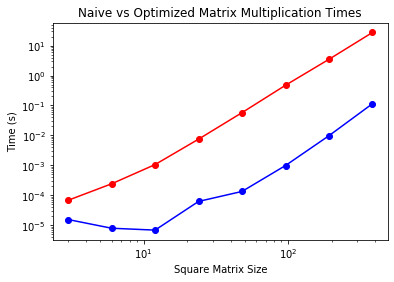

In [5]:
plt.plot(sizes, my_times, 'ro-', label="Naive")
plt.plot(sizes, np_times, 'bo-', label="Optimized")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Square Matrix Size")
plt.ylabel("Time (s)")
plt.title("Naive vs Optimized Matrix Multiplication Times")
plt.show()